# Realtime CTR Statistical Validity Analysis

This notebook evaluates whether the realtime CTR job produces statistically meaningful bucket estimates from the processed evidence. The analysis covers count conservation, Bayesian posterior behavior, estimator error against known synthetic probabilities, uncertainty contraction, calibration, feature-family effects, and production assumptions.

The dataset is the P2 periodic-persistence experiment with 200,000 impressions and 4,126 clicks (`20260719_165139`). Its deterministic seed and traffic generator make the true sampling probabilities available for validation. This is therefore a synthetic estimator-validity study, not proof of calibration on real user traffic.

The experiment artifact and configuration files are referenced relative to the repository root, so the notebook can be run from the project root or the `notebooks/` directory on any machine.

In [16]:
from __future__ import annotations

from collections import Counter
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import Markdown, display

from ctx_ctr.services.ctr_math import beta_variance, clipped_confidence_interval
from ctx_ctr.services.event_simulator import EventSimulatorService
from ctx_ctr.services.seed_values_dataset import build_seed_values_dataset

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the ctx-ctr repository")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
print("Project root resolved")

Project root resolved


## Analysis dataset and integrity

The integrity table verifies that the analyzed artifact is complete before any statistical interpretation is attempted. `measurement` names the check and `value` is the recorded result. Produced counts come from the Kafka producer; processed and dead-letter counts come from Flink; Redis deltas are aggregate changes across all CTR buckets; valid and trusted bucket counts describe final Redis state; and `success gates passed` summarizes the experiment's configured consistency checks.

In [17]:
ANALYSIS_RESULT = Path("experiments/results/20260719_165139_realtime_ctr_performance_baseline/result.json")
result = json.loads((PROJECT_ROOT / ANALYSIS_RESULT).read_text(encoding="utf-8"))
processor = result["metrics"]["processor_metrics"]["realtime_ctr"]["aggregate"]
producer = result["metrics"]["producer"]
statistics = result["metrics"]["statistics"]
gates = result["metrics"]["success_gates"]
traffic_phase = result["config"]["traffic"]["phases"][0]
processor_command = result["config"]["processors"]["realtime_ctr"]["command"]
parallelism_index = processor_command.index("--parallelism")
analysis_parallelism = int(processor_command[parallelism_index + 1])

integrity = pd.DataFrame({
    "measurement": [
        "parallelism", "produced impressions", "produced clicks",
        "produced total events", "processed events", "dead letters",
        "Redis impression delta", "Redis click delta",
        "valid buckets after", "trusted buckets after", "success gates passed",
    ],
    "value": [
        analysis_parallelism, producer["impressions"], producer["clicks"],
        producer["total_events"], int(processor["processed_events"]), int(processor["dead_letters"]),
        statistics["delta"]["redis_total_impressions"], statistics["delta"]["redis_total_clicks"],
        statistics["after"]["redis_valid_bucket_count"], statistics["after"]["redis_trusted_bucket_count"], gates["passed"],
    ],
})
integrity

,measurement,value
0,parallelism,2
1,produced impressions,200000
2,produced clicks,4126
3,produced total events,204126
4,processed events,204126
5,dead letters,0
6,Redis impression delta,200000
7,Redis click delta,4126
8,valid buckets after,100
9,trusted buckets after,100


## Estimator definition and assumptions

For each `(ad category, publisher domain, conversation category)` bucket, the model uses a logistic prior and a Beta-Binomial update:

```text
prior_ctr = sigmoid(w0 + w_ad[a] + w_dom[d] + w_ctx[c])
alpha_prior = prior_ctr * prior_strength
beta_prior  = (1 - prior_ctr) * prior_strength
alpha_post  = alpha_prior + clicks
beta_post   = beta_prior + impressions - clicks
posterior_ctr = alpha_post / (alpha_post + beta_post)
```

This Beta-Binomial estimator is appropriate when each impression is a Bernoulli opportunity, each opportunity has at most one click, bucket CTR is approximately stationary during the evidence window, and events are complete and deduplicated. The implementation is in [`realtime_ctr.py`](../src/ctx_ctr/services/realtime_ctr.py), with shared formulas in [`ctr_math.py`](../src/ctx_ctr/services/ctr_math.py).

## Bucket-state reconstruction and field reference

The experiment resets and seeds Redis before publishing a deterministic event batch. Rebuilding both inputs gives the expected state transition for all 100 triplet buckets. The saved artifact contains aggregate Redis statistics rather than every bucket payload, so reconstructed aggregates are required to match every recorded value.

Bucket table fields:

| Field | Meaning |
|---|---|
| `bucket` | Composite `ad_category:publisher_domain:conversation_category` key. |
| `ad_category`, `publisher_domain`, `conversation_category` | Feature values defining the triplet bucket. |
| `generator_ctr` | Known probability used by the simulator for this bucket; synthetic ground truth. |
| `seed_impressions`, `seed_clicks` | Deterministic counts present before the analyzed traffic batch. |
| `seed_raw_ctr` | `seed_clicks / seed_impressions`, without prior smoothing. |
| `seed_posterior_ctr` | Beta posterior mean stored in the seeded bucket. |
| `seed_ci_width` | Width of the seeded approximate confidence interval. |
| `batch_impressions`, `batch_clicks` | New evidence generated for the analyzed experiment. |
| `batch_raw_ctr` | `batch_clicks / batch_impressions`, using only new traffic. |
| `final_impressions`, `final_clicks` | Seed counts plus new batch counts. |
| `final_raw_ctr` | Combined unsmoothed CTR after the batch. |
| `final_posterior_ctr` | Updated Beta posterior mean after incorporating all final counts. |
| `final_variance` | Variance of the final Beta posterior. |
| `final_ci_low`, `final_ci_high`, `final_ci_width` | Lower bound, upper bound, and width of the clipped approximate 95% interval. |
| `final_trusted` | Whether final impressions, variance, and interval width satisfy runtime trust thresholds. |

The reconciliation table uses `recorded` for artifact values, `reconstructed` for values derived from the rebuilt buckets, and `difference` for `reconstructed - recorded`. Every difference must be zero within floating-point tolerance.

In [4]:
class NoopPublisher:
    def publish(self, event: object, *, also_unified: bool) -> None:
        pass

    def flush(self) -> None:
        pass

seed_config = yaml.safe_load((PROJECT_ROOT / "configs/seed_values.yaml").read_text(encoding="utf-8"))
realtime_config = yaml.safe_load((PROJECT_ROOT / "configs/run_realtime_ctr.yaml").read_text(encoding="utf-8"))
seed_dataset = build_seed_values_dataset(
    baseline_prior_mean=seed_config["baseline_prior_mean"],
    triplet_prior_strength=seed_config["triplet_prior_strength"],
    global_prior_strength=seed_config["global_prior_strength"],
    ad_prior_strength=seed_config["ad_prior_strength"],
    domain_prior_strength=seed_config["domain_prior_strength"],
    context_prior_strength=seed_config["context_prior_strength"],
)
simulator = EventSimulatorService(NoopPublisher())
batch = simulator.build_batch(traffic_phase["impressions"], traffic_phase["random_seed"])
impression_counts: Counter[tuple[str, str, str]] = Counter()
click_counts: Counter[tuple[str, str, str]] = Counter()
for event in batch.events:
    key = (event.ad_category, event.publisher_domain, event.conversation_category)
    if event.event_type == "impression":
        impression_counts[key] += 1
    else:
        click_counts[key] += 1

len(batch.events), batch.impression_count, batch.click_count, len(impression_counts)

(204126, 200000, 4126, 100)

In [5]:
bucket_rows: list[dict[str, object]] = []
for bucket in seed_dataset.bucket_statistics:
    key = (bucket.ad_category, bucket.publisher_domain, bucket.conversation_category)
    batch_impressions = impression_counts[key]
    batch_clicks = click_counts[key]
    final_impressions = bucket.impressions + batch_impressions
    final_clicks = bucket.clicks + batch_clicks
    alpha_posterior = bucket.alpha_prior + final_clicks
    beta_posterior = bucket.beta_prior + final_impressions - final_clicks
    posterior_ctr = alpha_posterior / (alpha_posterior + beta_posterior)
    variance = beta_variance(alpha_posterior, beta_posterior)
    ci_low, ci_high = clipped_confidence_interval(
        posterior_ctr, variance, realtime_config["trust_z_score"]
    )
    trusted = (
        final_impressions >= realtime_config["trust_min_impressions"]
        and variance <= realtime_config["trust_max_variance"]
        and (ci_high - ci_low) <= realtime_config["trust_max_ci_width"]
    )
    prior_ctr = bucket.alpha_prior / (bucket.alpha_prior + bucket.beta_prior)
    bucket_rows.append({
        "bucket": ":".join(key),
        "ad_category": key[0],
        "publisher_domain": key[1],
        "conversation_category": key[2],
        "generator_ctr": prior_ctr,
        "seed_impressions": bucket.impressions,
        "seed_clicks": bucket.clicks,
        "seed_raw_ctr": bucket.clicks / bucket.impressions,
        "seed_posterior_ctr": bucket.ctr,
        "seed_ci_width": bucket.ci_high - bucket.ci_low,
        "batch_impressions": batch_impressions,
        "batch_clicks": batch_clicks,
        "batch_raw_ctr": batch_clicks / batch_impressions,
        "final_impressions": final_impressions,
        "final_clicks": final_clicks,
        "final_raw_ctr": final_clicks / final_impressions,
        "final_posterior_ctr": posterior_ctr,
        "final_variance": variance,
        "final_ci_low": ci_low,
        "final_ci_high": ci_high,
        "final_ci_width": ci_high - ci_low,
        "final_trusted": trusted,
    })

buckets = pd.DataFrame(bucket_rows)
buckets.head()

,bucket,ad_category,publisher_domain,conversation_category,generator_ctr,seed_impressions,seed_clicks,seed_raw_ctr,seed_posterior_ctr,seed_ci_width,batch_impressions,batch_clicks,batch_raw_ctr,final_impressions,final_clicks,final_raw_ctr,final_posterior_ctr,final_variance,final_ci_low,final_ci_high,final_ci_width,final_trusted
0,finance:news.example:personal_finance,finance,news.example,personal_finance,0.029260,120,3,0.025000,0.026937,0.042691,2753,79,0.028696,2873,82,0.028542,0.028566,0.000009,0.022579,0.034553,0.011974,True
1,finance:news.example:trip_planning,finance,news.example,trip_planning,0.027336,150,4,0.026667,0.026935,0.040057,2645,73,0.027599,2795,77,0.027549,0.027542,0.000009,0.021581,0.033502,0.011921,True
2,finance:news.example:online_learning,finance,news.example,online_learning,0.025535,180,6,0.033333,0.030548,0.040243,2727,66,0.024202,2907,72,0.024768,0.024793,0.000008,0.019236,0.030350,0.011114,True
3,finance:news.example:wellness,finance,news.example,wellness,0.024084,210,4,0.019048,0.020672,0.031627,2518,65,0.025814,2728,69,0.025293,0.025251,0.000009,0.019469,0.031032,0.011562,True
4,finance:news.example:gaming,finance,news.example,gaming,0.020000,240,5,0.020833,0.020588,0.030144,2384,49,0.020554,2624,54,0.020579,0.020558,0.000007,0.015230,0.025886,0.010656,True


In [6]:
reconciliation = pd.DataFrame({
    "measurement": [
        "before impressions", "before clicks", "batch impressions", "batch clicks",
        "after impressions", "after clicks", "average CI width before",
        "average CI width after", "maximum CI width after",
    ],
    "recorded": [
        statistics["before"]["redis_total_impressions"],
        statistics["before"]["redis_total_clicks"],
        statistics["delta"]["redis_total_impressions"],
        statistics["delta"]["redis_total_clicks"],
        statistics["after"]["redis_total_impressions"],
        statistics["after"]["redis_total_clicks"],
        statistics["before"]["redis_average_ci_width"],
        statistics["after"]["redis_average_ci_width"],
        statistics["after"]["redis_max_ci_width"],
    ],
    "reconstructed": [
        buckets["seed_impressions"].sum(), buckets["seed_clicks"].sum(),
        buckets["batch_impressions"].sum(), buckets["batch_clicks"].sum(),
        buckets["final_impressions"].sum(), buckets["final_clicks"].sum(),
        buckets["seed_ci_width"].mean(), buckets["final_ci_width"].mean(),
        buckets["final_ci_width"].max(),
    ],
})
reconciliation["difference"] = reconciliation["reconstructed"] - reconciliation["recorded"]
assert np.allclose(reconciliation["difference"], 0.0)
assert int(buckets["final_trusted"].sum()) == statistics["after"]["redis_trusted_bucket_count"]
reconciliation

,measurement,recorded,reconstructed,difference
0,before impressions,"29,750.000000","29,750.000000",0.000000
1,before clicks,577.000000,577.000000,0.000000
2,batch impressions,"200,000.000000","200,000.000000",0.000000
3,batch clicks,"4,126.000000","4,126.000000",0.000000
4,after impressions,"229,750.000000","229,750.000000",0.000000
5,after clicks,"4,703.000000","4,703.000000",0.000000
6,average CI width before,0.028036,0.028036,-0.000000
7,average CI width after,0.011131,0.011131,-0.000000
8,maximum CI width after,0.013157,0.013157,0.000000


## Global sampling plausibility

Because the generator probability is known for every bucket, aggregate click volume can be tested against its expected distribution. `expected clicks` is the sum of bucket impressions multiplied by generator probability; `observed clicks` is the realized batch total. `expected CTR` and `observed CTR` divide those click totals by batch impressions. `observed minus expected` is their percentage-point difference. `standard error` is the Poisson-binomial standard error of aggregate CTR, and `z-score` expresses the observed difference in standard-error units.

In [7]:
total_batch_impressions = int(buckets["batch_impressions"].sum())
total_batch_clicks = int(buckets["batch_clicks"].sum())
expected_clicks = float((buckets["batch_impressions"] * buckets["generator_ctr"]).sum())
expected_ctr = expected_clicks / total_batch_impressions
observed_ctr = total_batch_clicks / total_batch_impressions
bernoulli_se = math.sqrt(float((
    buckets["batch_impressions"] * buckets["generator_ctr"] * (1 - buckets["generator_ctr"])
).sum())) / total_batch_impressions
global_z_score = (observed_ctr - expected_ctr) / bernoulli_se

global_metrics = pd.DataFrame({
    "metric": [
        "expected clicks", "observed clicks", "expected CTR", "observed CTR",
        "observed minus expected (percentage points)", "standard error", "z-score",
    ],
    "value": [
        expected_clicks, total_batch_clicks, expected_ctr, observed_ctr,
        100 * (observed_ctr - expected_ctr), bernoulli_se, global_z_score,
    ],
})
global_metrics

,metric,value
0,expected clicks,"4,214.992835"
1,observed clicks,"4,126.000000"
2,expected CTR,0.021075
3,observed CTR,0.020630
4,observed minus expected (percentage points),-0.044496
5,standard error,0.000321
6,z-score,-1.385999


## Bucket-level estimator quality

The generator CTR is the synthetic ground truth. Three estimators are compared: the seeded posterior before new traffic, raw CTR from only the new batch, and the final posterior after the update.

Quality table fields:

| Field | Meaning |
|---|---|
| `mean_bias_pp` | Mean signed estimate error in percentage points; positive means overestimation. |
| `mae_pp` | Mean absolute error in percentage points. |
| `rmse_pp` | Root mean squared error in percentage points, which penalizes large bucket errors more strongly. |
| `weighted_rmse_pp` | RMSE weighted by new bucket impressions, emphasizing high-traffic buckets. |
| `spearman_rank` | Rank correlation with generator CTR; `1.0` means perfect risk ordering. |

The scatter plot compares each estimate with perfect agreement, while the box plot shows signed error distributions.

In [8]:
def estimator_metrics(column: str, label: str) -> dict[str, object]:
    error = buckets[column] - buckets["generator_ctr"]
    rank_correlation = buckets[column].rank().corr(buckets["generator_ctr"].rank())
    return {
        "estimator": label,
        "mean_bias_pp": 100 * error.mean(),
        "mae_pp": 100 * error.abs().mean(),
        "rmse_pp": 100 * math.sqrt(float((error**2).mean())),
        "weighted_rmse_pp": 100 * math.sqrt(float(np.average(error**2, weights=buckets["batch_impressions"]))),
        "spearman_rank": rank_correlation,
    }

quality = pd.DataFrame([
    estimator_metrics("seed_posterior_ctr", "Seed posterior"),
    estimator_metrics("batch_raw_ctr", "New batch raw CTR"),
    estimator_metrics("final_posterior_ctr", "Final posterior"),
]).set_index("estimator")
quality

,mean_bias_pp,mae_pp,rmse_pp,weighted_rmse_pp,spearman_rank
estimator,,,,,
Seed posterior,-0.013221,0.194926,0.226898,0.231702,0.876431
New batch raw CTR,-0.043034,0.229282,0.299189,0.297071,0.777982
Final posterior,-0.038478,0.187595,0.250636,0.250556,0.821274


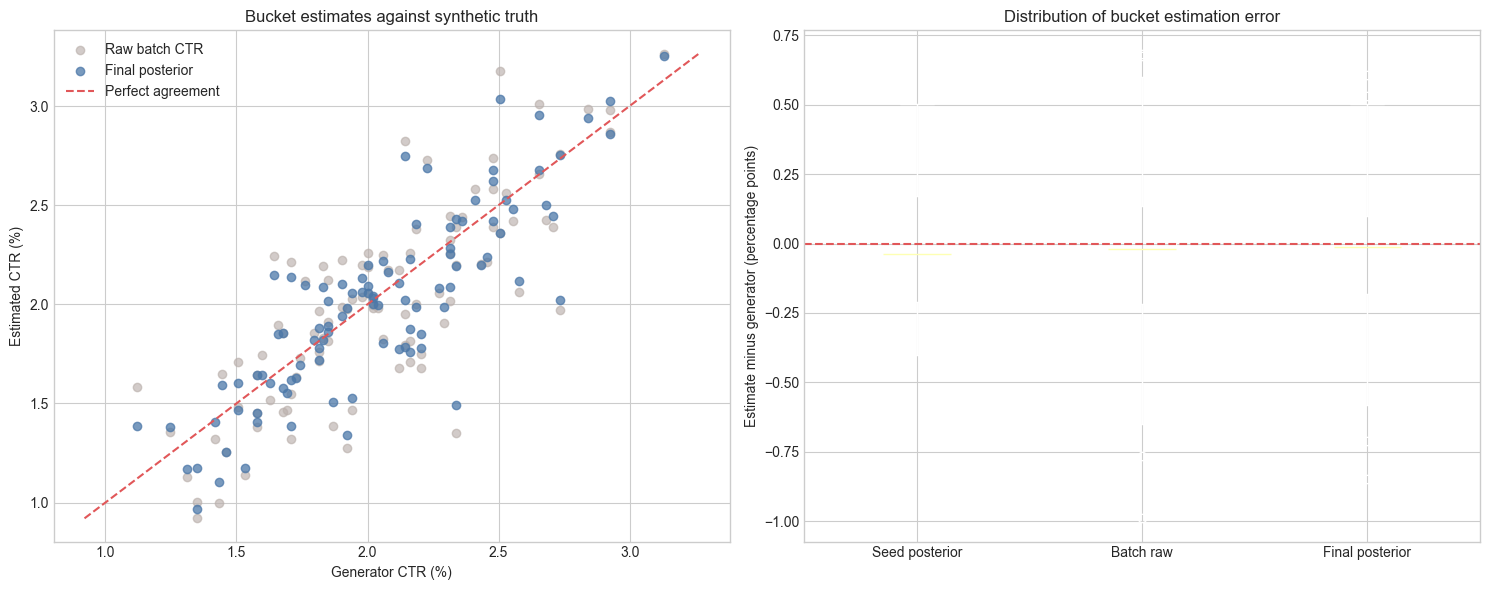

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
minimum = 100 * min(buckets["generator_ctr"].min(), buckets["batch_raw_ctr"].min())
maximum = 100 * max(buckets["generator_ctr"].max(), buckets["batch_raw_ctr"].max())
axes[0].scatter(100 * buckets["generator_ctr"], 100 * buckets["batch_raw_ctr"], alpha=0.65, label="Raw batch CTR", color="#BAB0AC")
axes[0].scatter(100 * buckets["generator_ctr"], 100 * buckets["final_posterior_ctr"], alpha=0.75, label="Final posterior", color="#4C78A8")
axes[0].plot([minimum, maximum], [minimum, maximum], linestyle="--", color="#E15759", label="Perfect agreement")
axes[0].set_xlabel("Generator CTR (%)")
axes[0].set_ylabel("Estimated CTR (%)")
axes[0].set_title("Bucket estimates against synthetic truth")
axes[0].legend()

error_data = [
    100 * (buckets["seed_posterior_ctr"] - buckets["generator_ctr"]),
    100 * (buckets["batch_raw_ctr"] - buckets["generator_ctr"]),
    100 * (buckets["final_posterior_ctr"] - buckets["generator_ctr"]),
]
axes[1].boxplot(error_data, tick_labels=["Seed posterior", "Batch raw", "Final posterior"], showfliers=True)
axes[1].axhline(0, linestyle="--", color="#E15759")
axes[1].set_ylabel("Estimate minus generator (percentage points)")
axes[1].set_title("Distribution of bucket estimation error")
plt.tight_layout()
plt.show()

## Posterior uncertainty and trust classification

The runtime uses a clipped normal approximation around the Beta posterior mean with `z = 1.96`. `minimum`, `median`, and `maximum new impressions` describe evidence distribution across buckets. Mean seed/final CI width measures average uncertainty before and after processing. `mean CI width reduction` is the proportional contraction. `generator coverage` is the fraction of intervals containing the known generator CTR. Trusted-bucket counts show how many buckets pass the configured impression, variance, and interval-width guards.

The normal approximation is reasonable at the final bucket sizes in this experiment, but exact Beta quantiles are preferable for low-count or near-boundary buckets.

In [10]:
buckets["generator_covered"] = (
    (buckets["generator_ctr"] >= buckets["final_ci_low"])
    & (buckets["generator_ctr"] <= buckets["final_ci_high"])
)
coverage = buckets["generator_covered"].mean()
ci_reduction = 1 - buckets["final_ci_width"].mean() / buckets["seed_ci_width"].mean()
uncertainty_summary = pd.DataFrame({
    "metric": [
        "minimum new impressions per bucket", "median new impressions per bucket",
        "maximum new impressions per bucket", "mean seed CI width",
        "mean final CI width", "mean CI width reduction",
        "generator coverage", "trusted buckets before", "trusted buckets after",
    ],
    "value": [
        buckets["batch_impressions"].min(), buckets["batch_impressions"].median(),
        buckets["batch_impressions"].max(), buckets["seed_ci_width"].mean(),
        buckets["final_ci_width"].mean(), ci_reduction, coverage,
        statistics["before"]["redis_trusted_bucket_count"], buckets["final_trusted"].sum(),
    ],
})
uncertainty_summary

,metric,value
0,minimum new impressions per bucket,"1,200.000000"
1,median new impressions per bucket,"1,986.500000"
2,maximum new impressions per bucket,"2,753.000000"
3,mean seed CI width,0.028036
4,mean final CI width,0.011131
5,mean CI width reduction,0.602961
6,generator coverage,0.970000
7,trusted buckets before,100.000000
8,trusted buckets after,100.000000


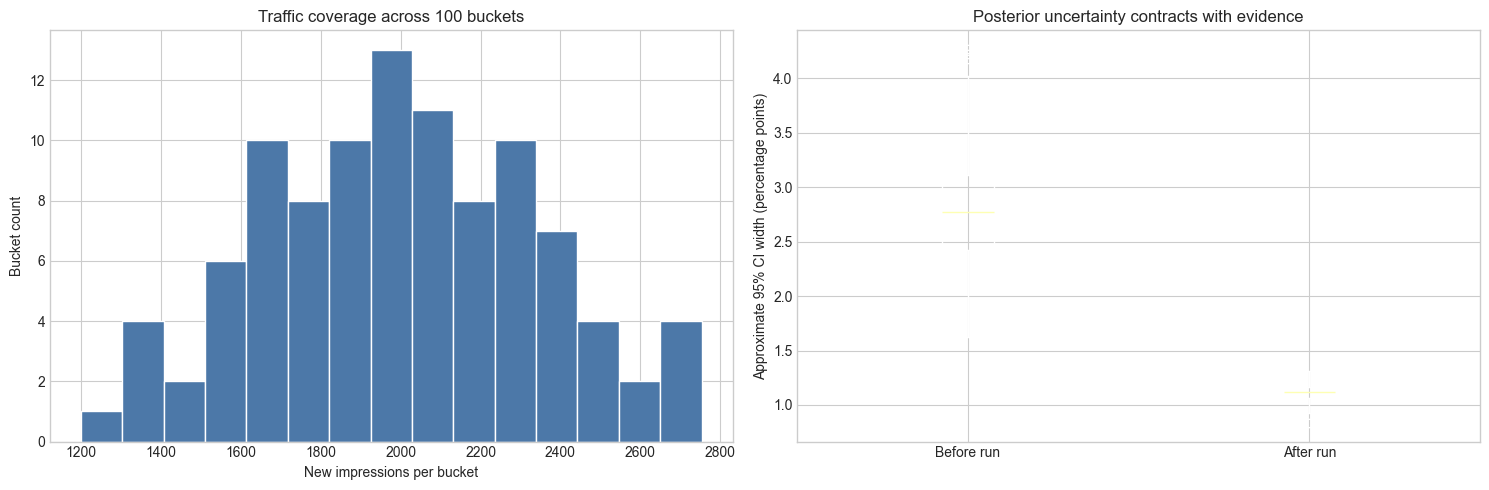

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(buckets["batch_impressions"], bins=15, color="#4C78A8", edgecolor="white")
axes[0].set_xlabel("New impressions per bucket")
axes[0].set_ylabel("Bucket count")
axes[0].set_title("Traffic coverage across 100 buckets")
axes[1].boxplot(
    [100 * buckets["seed_ci_width"], 100 * buckets["final_ci_width"]],
    tick_labels=["Before run", "After run"],
)
axes[1].set_ylabel("Approximate 95% CI width (percentage points)")
axes[1].set_title("Posterior uncertainty contracts with evidence")
plt.tight_layout()
plt.show()

## Calibration across CTR levels

Buckets are divided into five bands by known generator CTR. `band` contains the generator-probability interval. `expected_ctr` is the impression-weighted generator probability, `observed_ctr` is batch clicks divided by batch impressions, and `posterior_ctr` is the final posterior mean weighted by final impressions. Agreement and monotonic increase across bands indicate useful calibration and risk ordering.

,band,expected_ctr,observed_ctr,posterior_ctr
0,"(0.0102, 0.0168]",0.015036,0.014796,0.014805
1,"(0.0168, 0.0192]",0.017997,0.018289,0.018165
2,"(0.0192, 0.0214]",0.020328,0.020056,0.020070
3,"(0.0214, 0.0241]",0.022715,0.021326,0.021510
4,"(0.0241, 0.0313]",0.026569,0.026112,0.026127


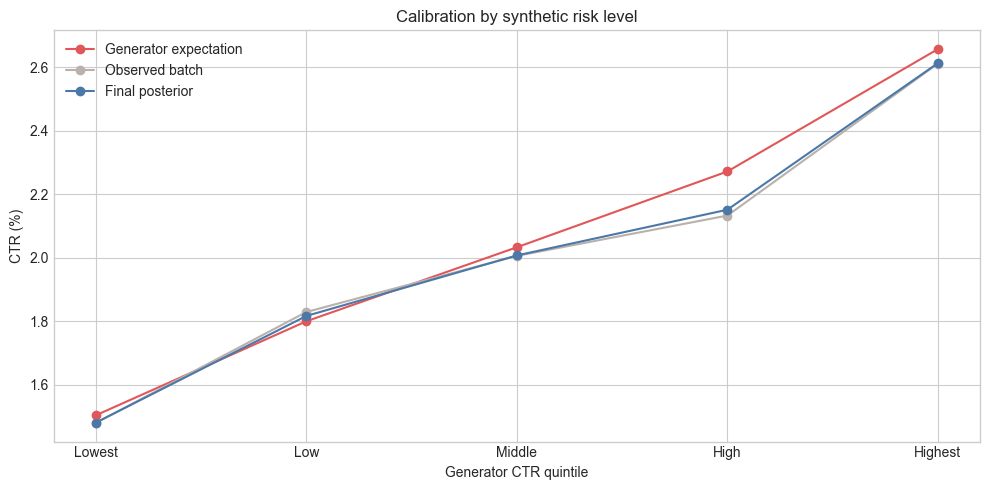

In [12]:
buckets["generator_band"] = pd.qcut(buckets["generator_ctr"], q=5, duplicates="drop")
calibration_rows: list[dict[str, float | str]] = []
for band, group in buckets.groupby("generator_band", observed=True):
    calibration_rows.append({
        "band": str(band),
        "expected_ctr": float(np.average(group["generator_ctr"], weights=group["batch_impressions"])),
        "observed_ctr": float(group["batch_clicks"].sum() / group["batch_impressions"].sum()),
        "posterior_ctr": float(np.average(group["final_posterior_ctr"], weights=group["final_impressions"])),
    })
calibration = pd.DataFrame(calibration_rows)
display(calibration)

x = np.arange(len(calibration))
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, 100 * calibration["expected_ctr"], marker="o", label="Generator expectation", color="#E15759")
ax.plot(x, 100 * calibration["observed_ctr"], marker="o", label="Observed batch", color="#BAB0AC")
ax.plot(x, 100 * calibration["posterior_ctr"], marker="o", label="Final posterior", color="#4C78A8")
ax.set_xticks(x, ["Lowest", "Low", "Middle", "High", "Highest"])
ax.set_xlabel("Generator CTR quintile")
ax.set_ylabel("CTR (%)")
ax.set_title("Calibration by synthetic risk level")
ax.legend()
plt.tight_layout()
plt.show()

## Feature-family aggregation

Aggregating buckets separately by ad category, publisher domain, and conversation category tests whether directional feature effects remain visible after sampling. `impressions` and `clicks` are new-batch totals for a feature value. `expected_ctr` is the impression-weighted generator probability, `observed_ctr` is the realized aggregate CTR, and `error_pp` is observed minus expected CTR in percentage points.

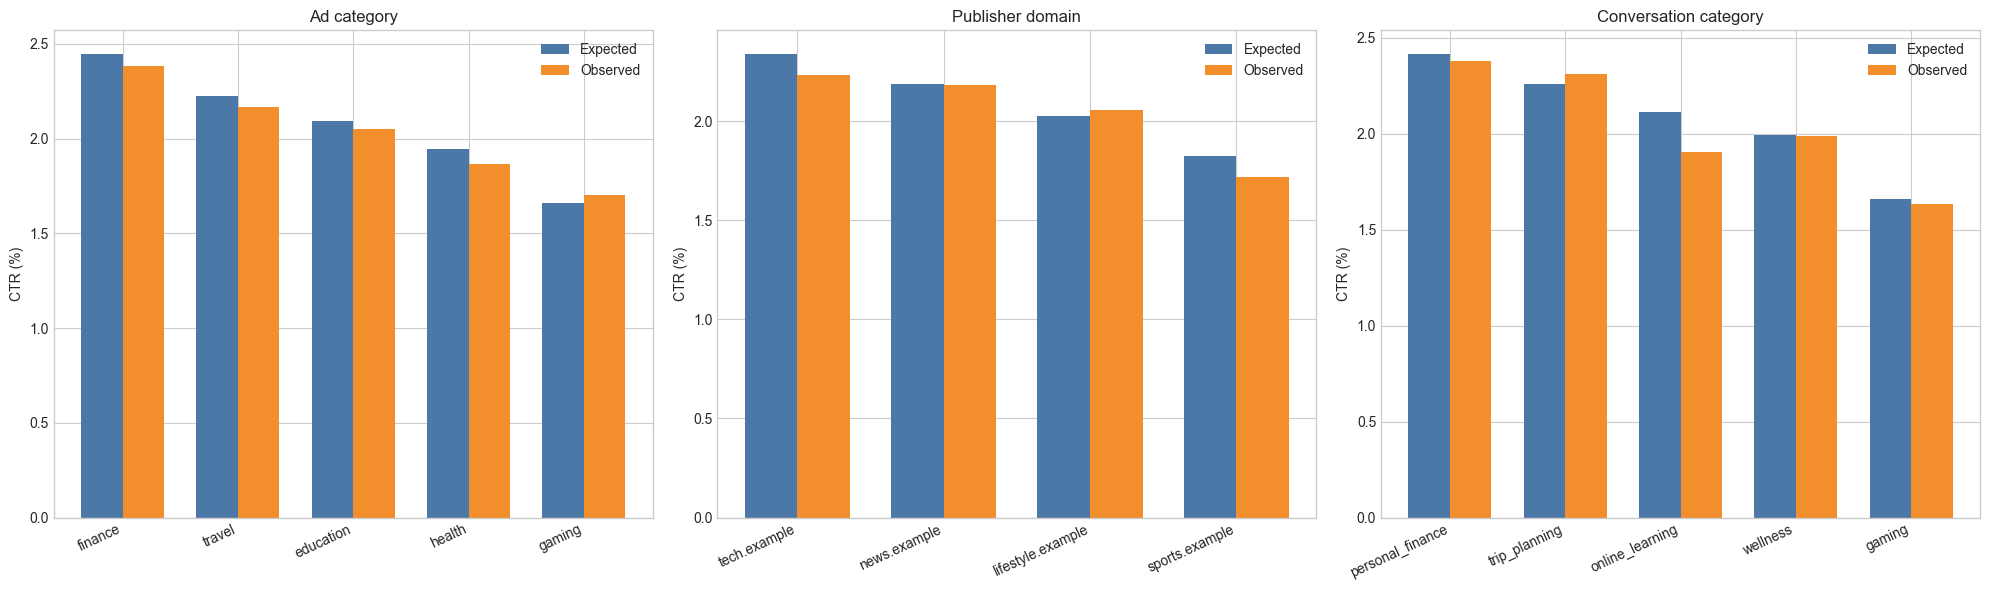

In [13]:
def aggregate_family(column: str) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for value, group in buckets.groupby(column):
        rows.append({
            column: value,
            "impressions": int(group["batch_impressions"].sum()),
            "clicks": int(group["batch_clicks"].sum()),
            "expected_ctr": float(np.average(group["generator_ctr"], weights=group["batch_impressions"])),
            "observed_ctr": float(group["batch_clicks"].sum() / group["batch_impressions"].sum()),
        })
    result = pd.DataFrame(rows).sort_values("expected_ctr", ascending=False)
    result["error_pp"] = 100 * (result["observed_ctr"] - result["expected_ctr"])
    return result

families = {
    "Ad category": aggregate_family("ad_category"),
    "Publisher domain": aggregate_family("publisher_domain"),
    "Conversation category": aggregate_family("conversation_category"),
}
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (title, frame) in zip(axes, families.items(), strict=True):
    label_column = frame.columns[0]
    x = np.arange(len(frame))
    ax.bar(x - 0.18, 100 * frame["expected_ctr"], width=0.36, label="Expected", color="#4C78A8")
    ax.bar(x + 0.18, 100 * frame["observed_ctr"], width=0.36, label="Observed", color="#F28E2B")
    ax.set_xticks(x, frame[label_column], rotation=25, ha="right")
    ax.set_title(title)
    ax.set_ylabel("CTR (%)")
    ax.legend()
plt.tight_layout()
plt.show()

## Largest bucket-level deviations

Aggregate accuracy can hide noisy individual buckets. This table ranks the ten largest absolute posterior errors. `posterior_error_pp` is signed final-posterior error in percentage points, `absolute_error_pp` is its magnitude, and `generator_covered` states whether the known generator CTR lies inside the reported final interval. The remaining count, CTR, and interval fields follow the bucket field reference above.

In [14]:
largest_errors = buckets.assign(
    posterior_error_pp=100 * (buckets["final_posterior_ctr"] - buckets["generator_ctr"]),
    absolute_error_pp=100 * (buckets["final_posterior_ctr"] - buckets["generator_ctr"]).abs(),
).nlargest(10, "absolute_error_pp")[[
    "bucket", "batch_impressions", "batch_clicks", "generator_ctr",
    "batch_raw_ctr", "final_posterior_ctr", "final_ci_low", "final_ci_high",
    "posterior_error_pp", "generator_covered",
]]
largest_errors

,bucket,batch_impressions,batch_clicks,generator_ctr,batch_raw_ctr,final_posterior_ctr,final_ci_low,final_ci_high,posterior_error_pp,generator_covered
47,education:tech.example:online_learning,2075,28,0.023389,0.013494,0.014917,0.010104,0.019730,-0.847160,False
7,finance:tech.example:online_learning,2336,46,0.027336,0.019692,0.020231,0.014878,0.025584,-0.710533,False
70,health:lifestyle.example:personal_finance,1982,56,0.021419,0.028254,0.027474,0.020896,0.034053,0.605534,True
75,health:sports.example:personal_finance,1804,23,0.019231,0.012749,0.013400,0.008632,0.018168,-0.583047,False
46,education:tech.example:trip_planning,2265,72,0.025042,0.031788,0.030368,0.023837,0.036898,0.532502,True
95,gaming:sports.example:personal_finance,1649,37,0.016434,0.022438,0.021469,0.015309,0.027629,0.503496,True
8,finance:tech.example:wellness,2229,46,0.025785,0.020637,0.021163,0.015609,0.026716,-0.462279,True
13,finance:lifestyle.example:wellness,2091,57,0.022274,0.027260,0.026887,0.020451,0.033322,0.461304,True
91,gaming:lifestyle.example:trip_planning,1673,37,0.017093,0.022116,0.021360,0.015235,0.027484,0.426608,True
35,travel:sports.example:personal_finance,2264,38,0.022057,0.016784,0.017800,0.012769,0.022832,-0.425698,True


## Domain validity assessment

### Estimator and state properties

- **Estimator:** Beta-Binomial smoothing is appropriate for binary click outcomes and avoids unstable raw CTRs in smaller buckets.
- **Prior structure:** `sigmoid(w0 + w_ad + w_dom + w_ctx)` gives an interpretable contextual prior in log-odds space.
- **Keyed state:** Flink `key_by` and `ValueState` serialize updates for each triplet bucket and make the count transition deterministic within the operator.
- **State contract:** `clicks <= impressions`, positive Beta parameters, bounded CTR, and ordered confidence bounds are validated by Pydantic.
- **Uncertainty:** variance, intervals, and a separate `trusted` classification are carried with every state snapshot.
- **Persistence semantics:** Redis receives complete latest-state snapshots, so coalescing writes changes I/O frequency without changing posterior calculations.

### Evidence supported by this experiment

- all produced events and Redis aggregate deltas reconcile;
- the posterior tracks known synthetic bucket probabilities;
- uncertainty contracts as impressions accumulate;
- risk ordering remains useful across buckets and feature families;
- periodic Redis flushing preserves final counts and posterior values.

## Conclusion

In [15]:
batch_raw_mae = float(quality.loc["New batch raw CTR", "mae_pp"])
posterior_mae = float(quality.loc["Final posterior", "mae_pp"])
mae_improvement = 100 * (1 - posterior_mae / batch_raw_mae)
posterior_rank = float(quality.loc["Final posterior", "spearman_rank"])
display(Markdown(f"""
### Statistical validity under the tested assumptions

The analyzed run observed **{observed_ctr:.3%} CTR** against a traffic-weighted generator expectation of **{expected_ctr:.3%}**. The difference is **{global_z_score:.2f} standard errors**, which is plausible sampling variation. Across 100 buckets, the final posterior achieves **{posterior_mae:.3f} percentage-point MAE**, improves MAE by **{mae_improvement:.1f}%** over the raw new-batch CTR, preserves a **{posterior_rank:.3f} Spearman rank correlation**, and its approximate 95% intervals cover the known generator rate in **{coverage:.1%}** of buckets. Mean CI width contracts by **{ci_reduction:.1%}**.

These results show that the CTR outputs are statistically coherent under the synthetic data-generating process: the job conserves evidence, performs Bayesian shrinkage, preserves directional effects, and expresses decreasing uncertainty. The estimator is suitable as a **v1 online CTR estimator for stable, well-defined buckets**.

### Scope limitations

The simulator samples from the same weights used by the prior. This is a self-consistency test, not evidence that the model will be calibrated on real traffic. It does not test misspecified priors, distribution drift, bots and repeated clicks or changing feature definitions. All 100 buckets are already trusted before traffic begins, so the trust transition and cold-start behavior are not exercised. After addressing these limitations and validate on real or shadow traffic we can proceed to using the posterior CTR directly in consequential ranking, bidding, or allocation decisions.
"""))


### Statistical validity under the tested assumptions

The analyzed run observed **2.063% CTR** against a traffic-weighted generator expectation of **2.107%**. The difference is **-1.39 standard errors**, which is plausible sampling variation. Across 100 buckets, the final posterior achieves **0.188 percentage-point MAE**, improves MAE by **18.2%** over the raw new-batch CTR, preserves a **0.821 Spearman rank correlation**, and its approximate 95% intervals cover the known generator rate in **97.0%** of buckets. Mean CI width contracts by **60.3%**.

These results show that the CTR outputs are statistically coherent under the synthetic data-generating process: the job conserves evidence, performs Bayesian shrinkage, preserves directional effects, and expresses decreasing uncertainty. The estimator is suitable as a **v1 online CTR estimator for stable, well-defined buckets**.

### Scope limitations

The simulator samples from the same weights used by the prior. This is a self-consistency test, not evidence that the model will be calibrated on real traffic. It does not test misspecified priors, distribution drift, bots and repeated clicks or changing feature definitions. All 100 buckets are already trusted before traffic begins, so the trust transition and cold-start behavior are not exercised. After addressing these limitations and validate on real or shadow traffic we can proceed to using the posterior CTR directly in consequential ranking, bidding, or allocation decisions.
